In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import json

In [2]:
# Path to photos.json
json_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.json"

# Load the JSON file
with open(json_path, "r") as f:
    photos_data = [json.loads(line) for line in f]

# Create a dictionary to map photo_id to label
photo_id_to_label = {item["photo_id"]: item["label"] for item in photos_data}

In [3]:
# Path to the photos folder
dataset_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"

# Function to load and preprocess images
def load_and_preprocess_image(img_path, img_size=(64, 64)):
    try:
        # Read the image file
        img = tf.io.read_file(img_path)
        # Decode the image to a tensor
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        # Resize the image
        img = tf.image.resize(img, img_size)
        # Normalize pixel values to [0, 1]
        img = img / 255.0
        return img
    except:
        # Skip corrupted or unsupported files
        return None

# Load a subset of images (e.g., 10,000 images)
image_paths = [
    os.path.join(dataset_path, filename) 
    for filename in os.listdir(dataset_path) 
    if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))
][:10000]  # Limit to 10,000 images

# Load images and labels
images = []
labels = []
for img_path in image_paths:
    photo_id = os.path.splitext(os.path.basename(img_path))[0]  # Extract photo_id from filename
    if photo_id in photo_id_to_label:  # Check if the photo_id exists in the JSON data
        img = load_and_preprocess_image(img_path)
        if img is not None:  # Only add valid images
            images.append(img)
            labels.append(photo_id_to_label[photo_id])

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

In [4]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
import numpy as np

# Apply Gaussian Blur, Histogram Equalization, and Intensity Thresholding
def preprocess_image_advanced(img):
    # Convert to numpy array (from tensor)
    img = np.array(img * 255, dtype=np.uint8)  # Convert back to 0-255 range

    # Convert back to 3 channels for CNN input
    processed_img = img / 255.0  # Normalize to [0,1]

    return processed_img

# Apply preprocessing to all images
images_processed = np.array([preprocess_image_advanced(img) for img in images])



In [5]:
from tensorflow.keras.layers import Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, LeakyReLU, BatchNormalization, Input
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

# Generator Model
def build_generator(noise_dim):
    noise = Input(shape=(noise_dim,))
    x = Dense(8 * 8 * 128)(noise)
    x = Reshape((8, 8, 128))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2DTranspose(3, (4, 4), strides=(2, 2), padding='same', activation='tanh')(x)

    model = Model(noise, x)
    return model

# Critic Model (WGAN doesn't use sigmoid)
def build_critic(img_shape):
    img = Input(shape=img_shape)
    
    x = Conv2D(64, (4, 4), strides=(2, 2), padding='same')(img)
    x = LeakyReLU(0.2)(x)

    x = Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2D(256, (4, 4), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Flatten()(x)
    x = Dense(1)(x)  # No sigmoid

    model = Model(img, x)
    return model

# Define shapes
noise_dim = 100
img_shape = (64, 64, 3)

generator = build_generator(noise_dim)
critic = build_critic(img_shape)


In [6]:
import tensorflow as tf

def gradient_penalty(real_images, fake_images):
    # Ensure both images and alpha are of the same type (float32)
    real_images = tf.cast(real_images, tf.float32)
    fake_images = tf.cast(fake_images, tf.float32)

    alpha = tf.random.uniform([real_images.shape[0], 1, 1, 1], 0.0, 1.0)
    alpha = tf.cast(alpha, tf.float32)  # Make sure alpha is float32

    # Now the operation should work without type mismatches
    interpolated_images = alpha * real_images + (1 - alpha) * fake_images

    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        interpolated_output = critic(interpolated_images, training=True)

    gradients = tape.gradient(interpolated_output, interpolated_images)
    norm = tf.sqrt(tf.reduce_sum(tf.square(gradients), axis=[1, 2, 3]))
    penalty = tf.reduce_mean((norm - 1.0) ** 2)
    return penalty


In [7]:
import tensorflow.keras.optimizers as optimizers

# Optimizers
generator_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
critic_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)

# Loss function for WGAN
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

@tf.function
def train_step(real_images):
    batch_size = real_images.shape[0]
    noise = tf.random.normal([batch_size, noise_dim])

    # Train Critic
    for _ in range(5):
        with tf.GradientTape() as tape:
            fake_images = generator(noise, training=True)
            real_output = critic(real_images, training=True)
            fake_output = critic(fake_images, training=True)

            gp = gradient_penalty(real_images, fake_images)
            critic_loss = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output) + 10 * gp

        gradients = tape.gradient(critic_loss, critic.trainable_variables)
        critic_optimizer.apply_gradients(zip(gradients, critic.trainable_variables))

    # Train Generator
    with tf.GradientTape() as tape:
        fake_images = generator(noise, training=True)
        fake_output = critic(fake_images, training=True)
        generator_loss = -tf.reduce_mean(fake_output)

    gradients = tape.gradient(generator_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients, generator.trainable_variables))

    return critic_loss, generator_loss


✅ Mixed Precision Enabled for Faster Training
Epoch: 0/50 | Critic Loss: -5647.6392 | Generator Loss: 3069.1733
Time: 420.22 sec | Elapsed: 7.00 min | Remaining: 343.18 min



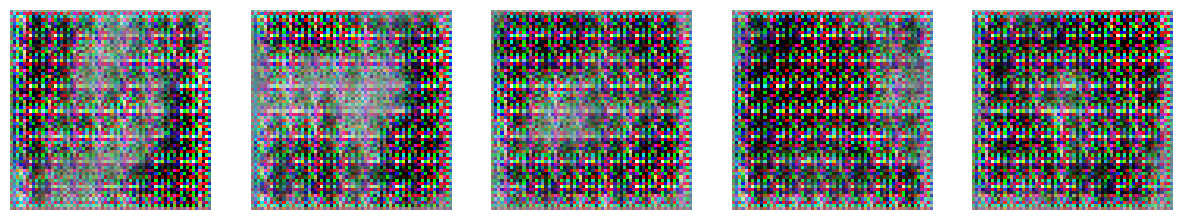

Epoch: 5/50 | Critic Loss: -39783.7969 | Generator Loss: 30651.7422
Time: 846.61 sec | Elapsed: 196.23 min | Remaining: 1438.99 min

Epoch: 10/50 | Critic Loss: -123803.6250 | Generator Loss: 78158.7500
Time: 452.34 sec | Elapsed: 239.63 min | Remaining: 849.57 min



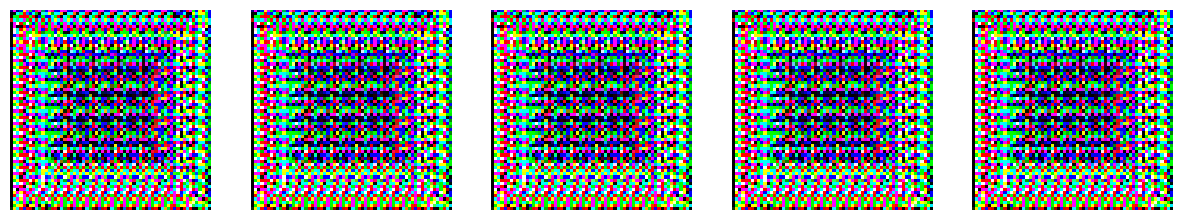

Epoch: 15/50 | Critic Loss: -90812.7500 | Generator Loss: 111231.3281
Time: 418.48 sec | Elapsed: 272.65 min | Remaining: 579.31 min

Epoch: 20/50 | Critic Loss: -375686.2188 | Generator Loss: 147453.8594
Time: 424.20 sec | Elapsed: 308.31 min | Remaining: 425.71 min



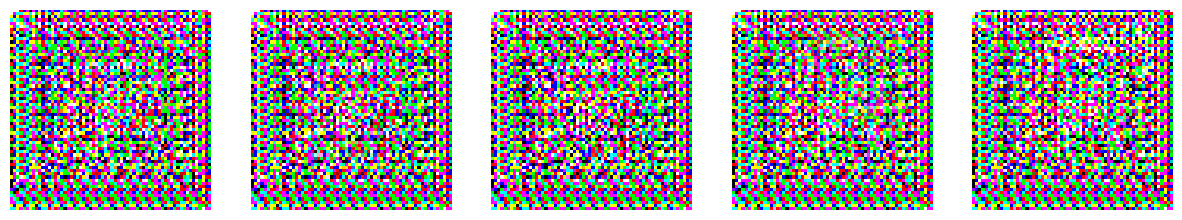

Epoch: 25/50 | Critic Loss: 41062.0938 | Generator Loss: 179852.2812
Time: 381.82 sec | Elapsed: 340.66 min | Remaining: 314.41 min

Epoch: 30/50 | Critic Loss: 4494633.0000 | Generator Loss: 235467.2812
Time: 421.09 sec | Elapsed: 373.86 min | Remaining: 229.10 min



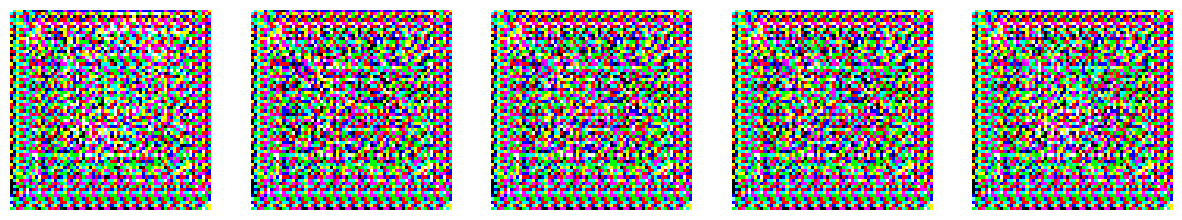

Epoch: 35/50 | Critic Loss: -730183.0625 | Generator Loss: 307368.4375
Time: 421.41 sec | Elapsed: 408.95 min | Remaining: 159.01 min

Epoch: 40/50 | Critic Loss: 71278.2188 | Generator Loss: 416358.0625
Time: 381.05 sec | Elapsed: 441.09 min | Remaining: 96.81 min



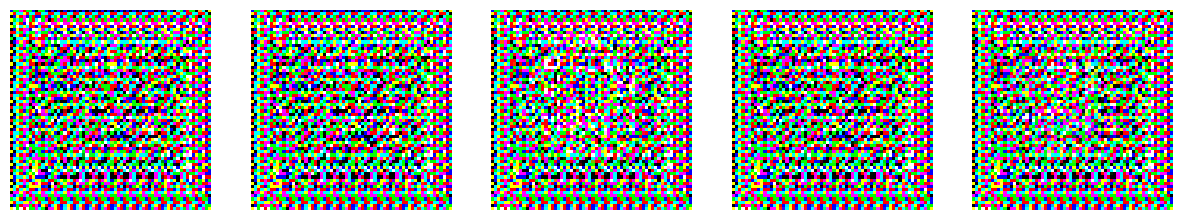

Epoch: 45/50 | Critic Loss: -253876.9688 | Generator Loss: 550001.5000
Time: 418.61 sec | Elapsed: 476.17 min | Remaining: 41.40 min

Epoch: 49/50 | Critic Loss: -580708.0625 | Generator Loss: 687454.4375
Time: 419.56 sec | Elapsed: 504.22 min | Remaining: 0.00 min


🎉 Training Completed! Total Time: 504.22 minutes


In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Enable mixed precision for faster GPU training (optional)
try:
    from tensorflow.keras.mixed_precision import set_global_policy
    set_global_policy('mixed_float16')
    print("✅ Mixed Precision Enabled for Faster Training")
except ImportError:
    print("⚠️ Mixed Precision not supported. Running with default precision.")

# Hyperparameters
epochs = 50  # Reduced for faster testing
batch_size = 32  # Smaller batch size for faster iterations
noise_dim = 100  # Dimension of noise vector for generator
epoch_times = []  # Store time taken for each epoch

# Convert dataset to TensorFlow pipeline for efficient loading
dataset = tf.data.Dataset.from_tensor_slices(images_processed)
dataset = dataset.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

start_total_time = time.time()  # Start overall timer

# Training Loop
for epoch in range(epochs):
    start_time = time.time()  # Start timer for each epoch

    # Training step for each batch
    for real_images in dataset:
        critic_loss, generator_loss = train_step(real_images)

    end_time = time.time()  # End timer for each epoch
    epoch_duration = end_time - start_time  # Time per epoch
    epoch_times.append(epoch_duration)

    # Calculate elapsed and remaining time
    avg_time_per_epoch = np.mean(epoch_times)  # Average time per epoch
    elapsed_time = time.time() - start_total_time  # Total elapsed time
    estimated_time_left = avg_time_per_epoch * (epochs - epoch - 1)  # Remaining estimated time

    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch: {epoch}/{epochs} | Critic Loss: {critic_loss:.4f} | Generator Loss: {generator_loss:.4f}")
        print(f"Time: {epoch_duration:.2f} sec | Elapsed: {elapsed_time/60:.2f} min | Remaining: {estimated_time_left/60:.2f} min\n")

    # Generate sample images every 10 epochs
    if epoch % 10 == 0:
        sample_images = generator(tf.random.normal([5, noise_dim]))  # Generate images
        sample_images = (sample_images * 127.5 + 127.5).numpy().astype('uint8')  # Normalize pixel values

        fig, axes = plt.subplots(1, 5, figsize=(15, 3))
        for i in range(5):
            axes[i].imshow(sample_images[i])
            axes[i].axis('off')
        plt.show()

# Print total training time after completion
total_training_time = time.time() - start_total_time
print(f"\n🎉 Training Completed! Total Time: {total_training_time/60:.2f} minutes")


In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model

def inception_score(images, num_splits=10):
    # Load pre-trained InceptionV3 model
    model = InceptionV3(include_top=True, weights="imagenet")
    model = Model(inputs=model.input, outputs=model.layers[-2].output)

    # Ensure images are in the correct format
    if isinstance(images, tf.Tensor):
        images = images.numpy()  # Convert TensorFlow Tensor to NumPy

    print(f"Original shape of images: {images.shape}")  # Debugging output

    # **REMOVE THIS INCORRECT RESHAPING STEP**
    # img_size = int(np.sqrt(images.shape[1] // 3))  # Unnecessary
    # images = images.reshape((-1, img_size, img_size, 3))  # REMOVE

    print(f"Final shape before resizing: {images.shape}")  # Debugging output

    images_resized = tf.image.resize(images, (299, 299))  # Resize for InceptionV3
    images_resized = preprocess_input(images_resized)  # Preprocess images

    preds = model.predict(images_resized)  # Get feature representations
    p_yx = tf.nn.softmax(preds).numpy()
    p_y = np.mean(p_yx, axis=0)

    scores = []
    for i in range(num_splits):
        part = p_yx[i * (len(p_yx) // num_splits):(i + 1) * (len(p_yx) // num_splits), :]
        kl = part * (np.log(part) - np.log(p_y))
        kl = np.sum(kl, axis=1)
        scores.append(np.exp(np.mean(kl)))

    return np.mean(scores), np.std(scores)

# Ensure noise_dim is defined
noise_dim = 100  # Adjust based on your model

# Generate fake images from your generator
num_samples = 500

if isinstance(generator, tf.keras.Model):  # If using TensorFlow/Keras model
    noise = tf.random.normal([num_samples, noise_dim])
    generated_images = generator(noise).numpy()

# **No need to reshape if already (500, 28, 28, 3)**
print(f"Final shape before Inception Score: {generated_images.shape}")  # Debugging output

# Compute Inception Score
mean_is, std_is = inception_score(generated_images)
print(f"Inception Score: {mean_is:.4f} ± {std_is:.4f}")


Final shape before Inception Score: (500, 28, 28, 3)
Original shape of images: (500, 28, 28, 3)
Final shape before resizing: (500, 28, 28, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step
Inception Score: 0.9995 ± 0.0005


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy.linalg import sqrtm

def calculate_fid(real_images, fake_images):
    # Load InceptionV3 model without the classification layer
    model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

    # Ensure inputs are NumPy arrays
    if isinstance(real_images, tf.Tensor):
        real_images = real_images.numpy()
    if isinstance(fake_images, tf.Tensor):
        fake_images = fake_images.numpy()

    print(f"Original shape of real images: {real_images.shape}")
    print(f"Original shape of fake images: {fake_images.shape}")

    # Resize and preprocess images
    real_images = tf.image.resize(real_images, (299, 299))
    fake_images = tf.image.resize(fake_images, (299, 299))

    real_images = preprocess_input(real_images.numpy())
    fake_images = preprocess_input(fake_images.numpy())

    print(f"Final shape before feature extraction - Real: {real_images.shape}, Fake: {fake_images.shape}")

    # Extract features using InceptionV3
    real_features = model.predict(real_images)
    fake_features = model.predict(fake_images)

    print(f"Feature shape - Real: {real_features.shape}, Fake: {fake_features.shape}")

    # Compute mean and covariance
    mu_real, sigma_real = np.mean(real_features, axis=0), np.cov(real_features, rowvar=False)
    mu_fake, sigma_fake = np.mean(fake_features, axis=0), np.cov(fake_features, rowvar=False)

    # Compute FID score
    ssdiff = np.sum((mu_real - mu_fake) ** 2)
    covmean = sqrtm(sigma_real @ sigma_fake)

    # Check for complex values and keep only real parts
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid_score = ssdiff + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid_score

# Select real images from dataset
num_samples = 500
real_images = next(iter(dataset))[:num_samples]

# Compute FID
fid = calculate_fid(real_images, generated_images)
print(f"FID Score: {fid:.4f}")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original shape of real images: (32, 64, 64, 3)
Original shape of fake images: (500, 28, 28, 3)
Final shape before feature extraction - Real: (32, 299, 299, 3), Fake: (500, 299, 299, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step
Feature shape - Real: (32, 2048), Fake: (500, 2048)
FID Score: 2.3875
